# Drug Review Sentiment Analysis — Exploratory Data Analysis

## Project Overview
Patient-reported experiences are one of the most underutilised sources of insight in drug safety and pharmacovigilance. Understanding what patients say about their medications — in their own words — can reveal patterns around adverse effects, treatment satisfaction, and unmet needs that clinical trials often miss.

The dataset includes information from Drugs.com reviews, sourced via UCI ML Repository, available on Kaggle. There are around 215,000 patient reviews. Columns included:
uniqueID - Unique ID
drugName - Name of drug reviewed, either generic or brand name
condition - Medical condition the patient was treating with the drug
review - Full text of the patient's written review
rating - Numerical rating given by the patient from 1 (worst) to 10 (best)
date - Date review was posted
usefulCount - Number of other users who found this review useful

The dataset contains data between 25/02/2008 and 12/12/2017.

## Objectives
- Understand the structure and quality of the data
- Identify missing values and data quality issues
- Explore the distribution of ratings and conditions as well as class balance
- Understand the most reviewed drugs and conditions
- Examine the nature and quality of the review text

## Notebook Structure

This notebook is organised into the following sections:

1. **Libraries and Configuration** — importing required libraries
2. **Data Loading** — loading and combining train and test datasets
3. **Dataset Overview** — shape, data types and initial inspection
4. **Missing Value Analysis** — identifying null and non-standard 
   missing values
5. **Rating Distribution** — exploring the distribution of patient 
   ratings and class imbalance
6. **Top Drugs and Conditions** — identifying the most reviewed 
   drugs and therapeutic areas
7. **Review Text Analysis** — examining review length, character 
   count, common words and short review thresholds
8. **Raw Text Quality Assessment** — inspecting raw text for HTML 
   encoding, noise and sentiment-rating alignment
9. **Key Findings Summary** — consolidated findings and 
   preprocessing decisions for Phase 2

### Libraries and Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import Counter
import re


warnings.filterwarnings("ignore")

## Data Loading

The dataset is provided as two separate files — a training set and a test set. 
For exploratory data analysis, both files are combined to give a complete view 
of the full dataset. The original split will be preserved for model evaluation 
in Phase 3.

In [2]:
df_train = pd.read_csv('data/drugsComTrain_raw.csv')
df_test = pd.read_csv('data/drugsComTest_raw.csv')                      

In [3]:
df_train['split'] = 'train'
df_test['split'] = 'test'

df = pd.concat([df_train, df_test], ignore_index=True)

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"Combined shape: {df.shape}")

Train shape: (161297, 8)
Test shape: (53766, 8)
Combined shape: (215063, 8)


In [4]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount,split
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27,train
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192,train
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17,train
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10,train
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37,train


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 215063 entries, 0 to 215062
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   uniqueID     215063 non-null  int64
 1   drugName     215063 non-null  str  
 2   condition    213869 non-null  str  
 3   review       215063 non-null  str  
 4   rating       215063 non-null  int64
 5   date         215063 non-null  str  
 6   usefulCount  215063 non-null  int64
 7   split        215063 non-null  str  
dtypes: int64(3), str(5)
memory usage: 13.1 MB


In [6]:
#Convert date to correct format
df['date'] = pd.to_datetime(df['date'])
df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])


In [7]:
print("=== NULL VALUES ===")
print(df.isnull().sum())

print("\n=== EMPTY STRINGS ===")
print((df == '').sum())

print("\n=== WHITESPACE ONLY ===")
print((df.apply(lambda x: x.astype(str).str.strip() == '').sum()))

=== NULL VALUES ===
uniqueID          0
drugName          0
condition      1194
review            0
rating            0
date              0
usefulCount       0
split             0
dtype: int64

=== EMPTY STRINGS ===
uniqueID       0
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
split          0
dtype: int64

=== WHITESPACE ONLY ===
uniqueID       0
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
split          0
dtype: int64


In [8]:
placeholders = ['N/A', 'n/a', 'NA', 'None', 'none', 'unknown', 'Unknown', '-', '--', 'nan']
for placeholder in placeholders:
    count = (df == placeholder).sum()
    if count.any():
        print(f"'{placeholder}' found:")
        print(count[count > 0])

In [9]:
df['condition'].value_counts().tail(25)

condition
Scleroderma                                     1
Tinea Barbae                                    1
62</span> users found this comment helpful.     1
92</span> users found this comment helpful.     1
Rat-bite Feve                                   1
Uveitis, Posteri                                1
Premature Ejaculation                           1
Jet Lag                                         1
Myotonia Congenita                              1
Hemorrhoids (pramoxine / zinc oxide)            1
Somat                                           1
37</span> users found this comment helpful.     1
Nausea (phosphorated carbohydrate solution)     1
83</span> users found this comment helpful.     1
Tympanostomy Tube Placement Surgery             1
Pulmonary Edema                                 1
70</span> users found this comment helpful.     1
Lyme Disease, Erythema Chronicum Migrans        1
100</span> users found this comment helpful.    1
Yellow Fever Prophylaxis                

The 'condition' column has 1194 missing values. There also seems to be some columns that look like HTML fragments, rather than real conditions. 
The other columns do not have missing data

In [10]:
df['rating'].describe()

count    215063.000000
mean          6.990008
std           3.275554
min           1.000000
25%           5.000000
50%           8.000000
75%          10.000000
max          10.000000
Name: rating, dtype: float64

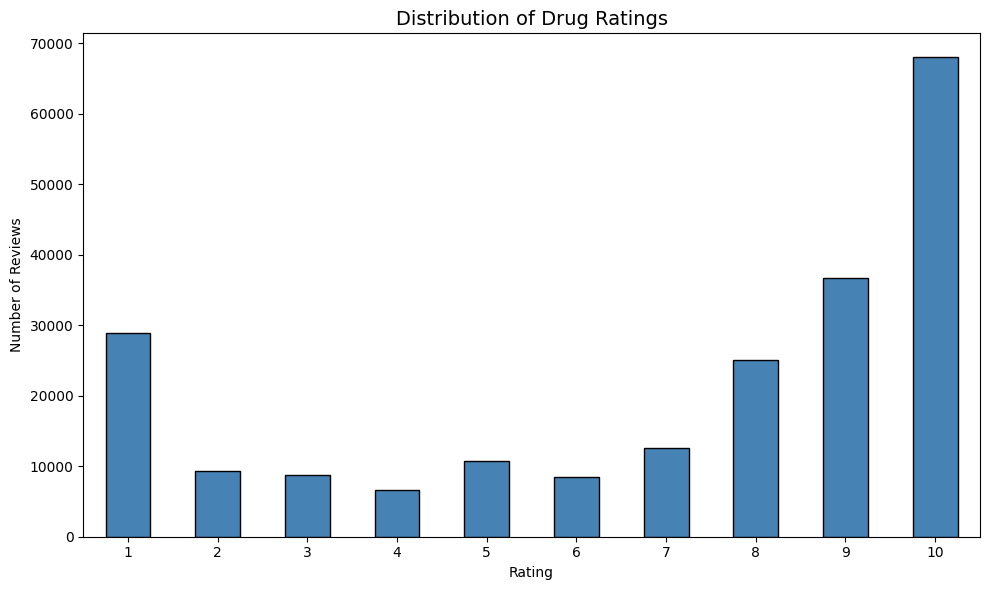

In [11]:
plt.figure(figsize=(10, 6))
df['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribution of Drug Ratings', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Ratings - Key Findings
The distribution is bimodal and heavily skewed positive:

- Rating 10 dominates with nearly 68,000 reviews — by far the most common rating
- Rating 9 is the second most common at around 37,000
- Rating 1 is surprisingly high at around 29,000 — the third most common rating
- Ratings 4, 5 and 6 are the least common — people rarely leave neutral reviews
- This classic U-shaped pattern is typical of review datasets — people tend to review when they feel strongly, either very positively or very negatively

**Implication for modelling:** The dataset has a significant positive class imbalance which will need to be addressed when creating sentiment labels

In [12]:
top_10_drugs = pd.DataFrame({
    'Drug Name': df['drugName'].value_counts().head(10).index,
    'Count': df['drugName'].value_counts().head(10).values,
    'Percentage (%)': (df['drugName'].value_counts(normalize=True)
                       .mul(100)
                       .round(2)
                       .head(10)
                       .values)
})

print(top_10_drugs)

                            Drug Name  Count  Percentage (%)
0                      Levonorgestrel   4930            2.29
1                        Etonogestrel   4421            2.06
2   Ethinyl estradiol / norethindrone   3753            1.75
3                           Nexplanon   2892            1.34
4    Ethinyl estradiol / norgestimate   2790            1.30
5  Ethinyl estradiol / levonorgestrel   2503            1.16
6                         Phentermine   2085            0.97
7                          Sertraline   1868            0.87
8                        Escitalopram   1747            0.81
9                              Mirena   1673            0.78


<Figure size 1200x600 with 0 Axes>

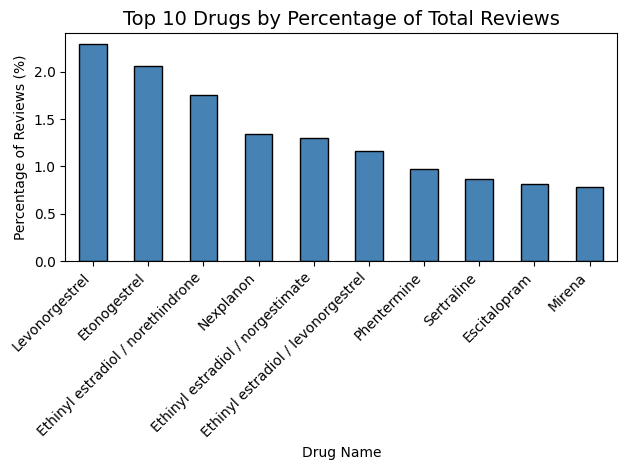

In [13]:
plt.figure(figsize=(12, 6))
top_10_drugs.plot(kind='bar', x='Drug Name', y='Percentage (%)', 
                  color='steelblue', edgecolor='black', legend=False)
plt.title('Top 10 Drugs by Percentage of Total Reviews', fontsize=14)
plt.xlabel('Drug Name')
plt.ylabel('Percentage of Reviews (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
top_10_conditions = pd.DataFrame({
    'Condition': df['condition'].value_counts().head(10).index,
    'Count': df['condition'].value_counts().head(10).values,
    'Percentage (%)': (df['condition'].value_counts(normalize=True)
                       .mul(100)
                       .round(2)
                       .head(10)
                       .values)
})

print(top_10_conditions)

         Condition  Count  Percentage (%)
0    Birth Control  38436           17.97
1       Depression  12164            5.69
2             Pain   8245            3.86
3          Anxiety   7812            3.65
4             Acne   7435            3.48
5  Bipolar Disorde   5604            2.62
6         Insomnia   4904            2.29
7      Weight Loss   4857            2.27
8          Obesity   4757            2.22
9             ADHD   4509            2.11


<Figure size 1200x600 with 0 Axes>

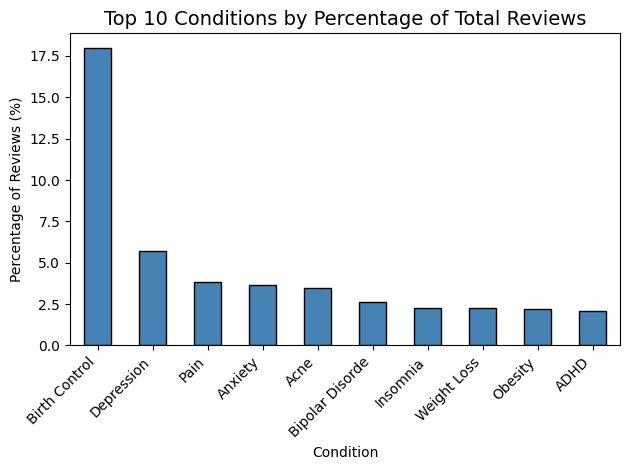

In [15]:
plt.figure(figsize=(12, 6))
top_10_conditions.plot(kind='bar', x='Condition', y='Percentage (%)', 
                  color='steelblue', edgecolor='black', legend=False)
plt.title('Top 10 Conditions by Percentage of Total Reviews', fontsize=14)
plt.xlabel('Condition')
plt.ylabel('Percentage of Reviews (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Top Drugs and Conditions — Key Findings

Seven of the top 10 most reviewed drugs are contraceptives, collectively 
accounting for approximately 18% of all reviews in the dataset. This 
concentration reflects the strong patient engagement around hormonal 
contraception, where side effect experiences vary significantly between 
individuals.

Depression is the second most represented condition, with 2 of the top 10 
drugs used as antidepressants. Reviews in this category tend to be 
detailed and emotionally rich, which is likely to be valuable for 
sentiment and topic analysis.

*It is important to note that reviews in the mental health category 
frequently describe serious and sensitive experiences. Results and 
findings in this area should be interpreted with appropriate 
clinical context.*

**Implication for modelling:** The dataset is not evenly distributed across 
therapeutic areas. Results and themes identified in the sentiment analysis 
will reflect this concentration, particularly around contraception and 
mental health medications.

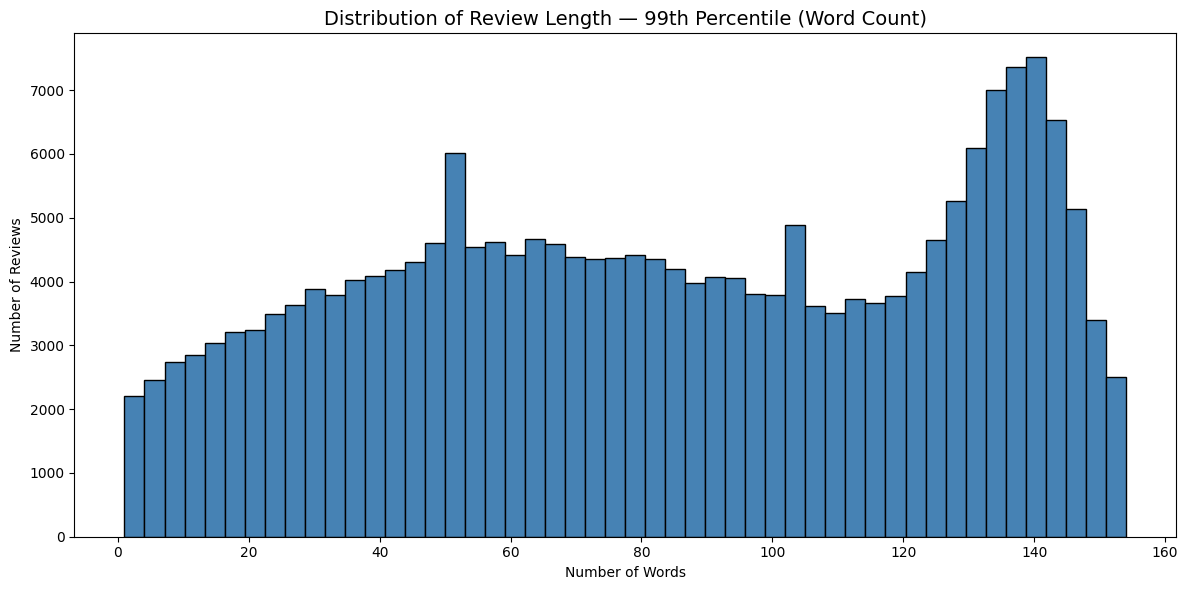

In [16]:
df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

cap = df['review_length'].quantile(0.99)

plt.figure(figsize=(12, 6))
df[df['review_length'] <= cap]['review_length'].plot(kind='hist', bins=50, 
                                                      color='steelblue', 
                                                      edgecolor='black')
plt.title('Distribution of Review Length — 99th Percentile (Word Count)', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [17]:
print(df['review_length'].describe())
print(f"\n99th percentile: {df['review_length'].quantile(0.99):.0f} words")
print(f"Reviews under 10 words: {(df['review_length'] < 10).sum()}")
print(f"Reviews over 500 words: {(df['review_length'] > 500).sum()}")

count    215063.000000
mean         84.682228
std          44.852532
min           1.000000
25%          48.000000
50%          84.000000
75%         126.000000
max        1894.000000
Name: review_length, dtype: float64

99th percentile: 154 words
Reviews under 10 words: 6436
Reviews over 500 words: 36


## Review Length Analysis — Key Findings

The dataset contains 215,063 reviews with a mean length of 85 words and a median of 84 words, indicating a fairly symmetrical distribution once extreme outliers are removed.

The distribution shows two peaks at approximately 50 and 135 words, suggesting possible platform-imposed length guidelines on Drugs.com at different points in time.

Key statistics:
- 6,436 reviews (3%) contain fewer than 10 words and carry limited NLP signal — these will be considered for removal in the next phase
- Only 36 reviews exceed 500 words — negligible and will be retained
- 99th percentile sits at 154 words confirming the vast majority of reviews are within a manageable length for transformer models

Overall the review length is well suited for NLP modelling — reviews are substantive enough to carry meaningful sentiment signal without being excessively long.

count    215063.000000
mean        458.620748
std         240.995226
min           3.000000
25%         262.000000
50%         456.000000
75%         690.000000
max       10787.000000
Name: char_count, dtype: float64


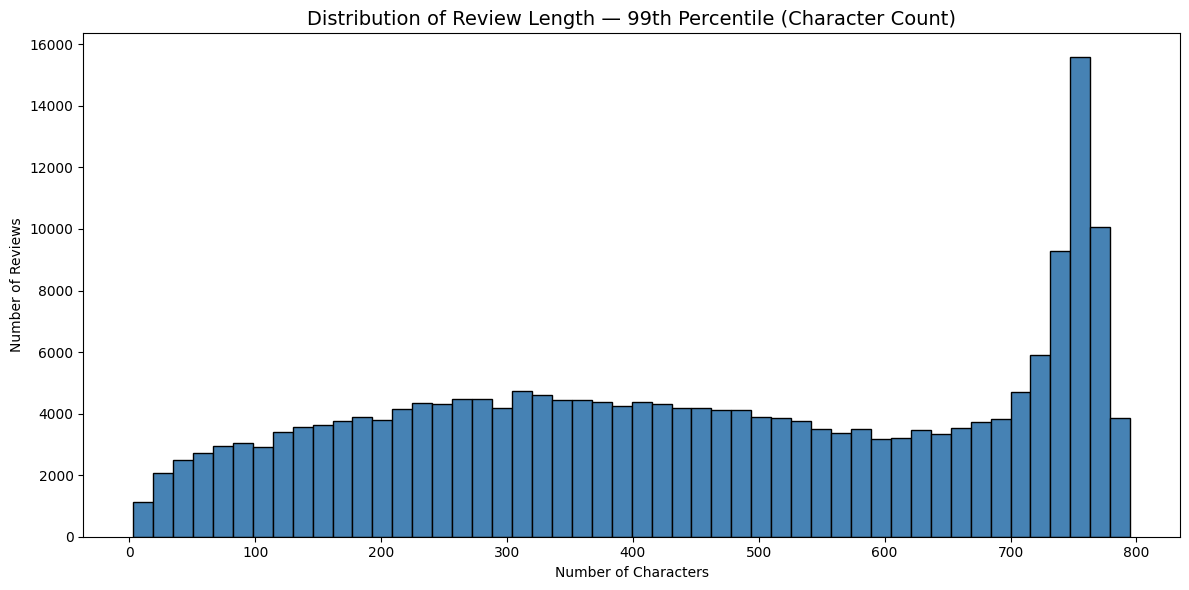

In [18]:
# Add character count column
df['char_count'] = df['review'].apply(lambda x: len(str(x)))

# Summary statistics
print(df['char_count'].describe())

# Plot distribution up to 99th percentile
cap = df['char_count'].quantile(0.99)

plt.figure(figsize=(12, 6))
df[df['char_count'] <= cap]['char_count'].plot(kind='hist', bins=50, 
                                                color='steelblue', 
                                                edgecolor='black')
plt.title('Distribution of Review Length — 99th Percentile (Character Count)', fontsize=14)
plt.xlabel('Number of Characters')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

## Character Count Analysis

The character count analysis confirms and complements the word count findings. The dataset shows a mean of 458 characters and a median of 
456 characters — the close alignment between these two values confirms a symmetrical distribution once extreme outliers are excluded.

**Key statistics:**
- Minimum: 3 characters — the shortest reviews are effectively 
  meaningless for NLP purposes
- Maximum: 10,787 characters — extreme outlier consistent with 
  the 1,894 word maximum seen in the word count analysis
- 50% of reviews fall between 262 and 690 characters, representing 
  substantive and usable text

**Notable pattern:** The chart shows a sharp spike at approximately 750 characters, mirroring the spike observed at around 135-140 words in the word count distribution. This is consistent — at an average of 5 characters per word, 140 words equates to roughly 700 characters. This reinforces the suggestion that Drugs.com may have had a platform character limit that many users wrote up to.

**Consistency with word count findings:** The character count distribution closely mirrors the word count distribution in shape, which is expected and provides confidence that the review_length column is a reliable measure of review substance. Both metrics will inform the minimum length threshold decision in the next phase.

In [19]:
# See what the shortest reviews actually say
print(df[df['char_count'] < 20][['drugName', 'review', 'rating']].head(10).to_string())

                             drugName               review  rating
371           Ledipasvir / sofosbuvir           "Headache"      10
393                           Mylanta  "Works every time."      10
517                          Morphine    "Stops the pain."      10
708           Clindamycin / tretinoin       "Dont know..."       2
987                           Vytorin    "Very effective."      10
1090  Amphetamine / dextroamphetamine              "Great"      10
1112                          Effexor     "Great miracle."      10
1285                    Phenylephrine     "Absolute BEST "      10
1616                       Mometasone      "Good medicine"      10
1879                           Celexa  "Suicidal thoughts"       3


## Short Review Analysis — Under 20 Characters

A sample of the shortest reviews reveals several important findings for preprocessing decisions in Phase 2.

**Limited NLP signal** — The majority of very short reviews consist of single words or brief phrases such as "Great" or "Good medicine." While these align with their ratings, they provide insufficient linguistic context for transformer-based sentiment modelling and topic extraction.

**Label noise risk** — "Headache" rated 10 illustrates how short reviews can be misleading. Without surrounding context it is impossible to determine whether the patient is describing a side effect or commenting on the drug's effectiveness. Short reviews introduce label noise that could negatively impact model performance.

**Clinically significant exceptions** — "Suicidal thoughts" for Celexa (rating 3) demonstrates that brief reviews can carry extreme clinical meaning. Celexa carries a black box warning for suicidal ideation. However despite their clinical significance, two-word reviews provide insufficient context for reliable NLP modelling.

**Phase 2 decision** — Reviews under 10 words (6,436 reviews, approximately 3% of the dataset) will be removed in Phase 2. The loss of 3% of data is acceptable given the disproportionate noise these reviews introduce. The minimum threshold of 10 words is considered sufficient to capture basic sentiment context while removing the most problematic entries.

In [20]:
print("=== RATING 10 REVIEWS ===")
for review in df[df['rating'] == 10]['review'].sample(3, random_state=42).values:
    print(review)
    print("---")

print("\n=== RATING 1 REVIEWS ===")
for review in df[df['rating'] == 1]['review'].sample(3, random_state=42).values:
    print(review)
    print("---")

=== RATING 10 REVIEWS ===
"I don&#039;t know what I did but whenever I jumped on the trampoline with my kids, I was experiencing some weird pain in my upper back.  I put some a535 on my back. That didn&#039;t help. The next day it still hurt!! Then I took two aleve pills and the next morning I was ok. And I continued this way for a few days and my back was all better!!! Thanks aleve! "
---
"Y&#039;all! -- I am one of these people who cannot say enough about bupropion! It has changed my life after only day 8. 
Such a subtle but powerful shift in perception and decrease in troublesome habits (smoking one of them, but also irrational anxiety getting on train, rushing down the street for no reason, rushing through dinner) has decreased by drinking, made me less weighed down. 
There are side effects the first few days but they will go away! Stick with it and you won&#039;t regret it ~"
---
"I have used this medication for about a year now. I have had migraines, but I have them in my genetic

## Raw Text Quality Assessment

A sample of reviews at both ends of the rating scale reveals several text quality issues that will require addressing in Phase 2:

**HTML encoding** — Reviews contain HTML entities such as &#039; (apostrophe) and &amp; (ampersand) left over from web scraping. These must be decoded before modelling.

**Numbers and dosages** — Reviews frequently reference specific dosages (e.g. 50mg, 100mg) and quantities. These carry clinical context but add noise to sentiment analysis and will be removed.

**Abbreviations** — Domain-specific abbreviations are common (e.g. bc, dr, appt). These are largely interpretable by transformer models and will be retained.

**Informal language** — Slang, colloquialisms and emoticons (e.g. lol) are present throughout. Transformer models trained on internet text handle these well and aggressive filteringis not warranted.

**Spelling and grammatical errors** — Expected in patient-authored reviews. Transformer models are generally robust to this level of noise.

**Sentiment-Rating Alignment** — A manual review of samples at both ends of the rating scale confirms strong alignment between the written review and the numeric rating. High-rated reviews (9-10) contain clearly positive language around efficacy and satisfaction, while low-rated reviews (1-2) consistently describe negative experiences, side effects and treatment failures. This alignment validates the use of numeric ratings as sentiment labels in Phase 2 and suggests low label noise in the resulting training data.

Overall the text is noisy but rich in sentiment signal. The cleaning strategy in Phase 2 will focus on HTML decoding and removing dosage references while preserving the natural language as much as possible.

In [21]:
print(f"Date range: {df['date'].min()} - {df['date'].max()}")

Date range: 2008-02-24 00:00:00 - 2017-12-12 00:00:00


In [22]:
# Basic cleaning just for this analysis - not final clean
def basic_clean(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  
    return text

# Common English stop words to remove
stop_words = set([
    'i', 'me', 'my', 'the', 'a', 'an', 'and', 'or', 'but', 'in', 
    'on', 'at', 'to', 'for', 'of', 'with', 'is', 'was', 'it', 
    'this', 'that', 'have', 'had', 'be', 'been', 'are', 'were',
    'not', 'no', 'so', 'do', 'did', 'has', 'he', 'she', 'they',
    'we', 'you', 'as', 'from', 'by', 'its', 'if', 'about', 'after',
    'before', 'just', 'also', 'very', 'would', 'could', 'when',
    'which', 'there', 'their', 'what', 'all', 'been', 'more', 'up'
])

# Combine all review text and count words
all_words = []
for review in df['review']:
    cleaned = basic_clean(review)
    words = [w for w in cleaned.split() if w not in stop_words and len(w) > 2]
    all_words.extend(words)

word_freq = Counter(all_words)
top_30 = pd.DataFrame(word_freq.most_common(30), columns=['Word', 'Count'])
print(top_30)

          Word  Count
0          day  74784
1          now  73369
2         side  69994
3       taking  68239
4          ive  62278
5        years  62251
6        first  59849
7         pain  59676
8      effects  58964
9         take  58307
10      months  57147
11        only  56849
12     started  56432
13        like  55497
14         get  55023
15        days  53903
16        time  51310
17         out  50643
18        feel  47366
19     because  41859
20        back  41332
21        pill  41012
22         one  39946
23       weeks  39741
24        week  37871
25        took  37382
26      period  36813
27  medication  36747
28      doctor  36577
29      weight  36416


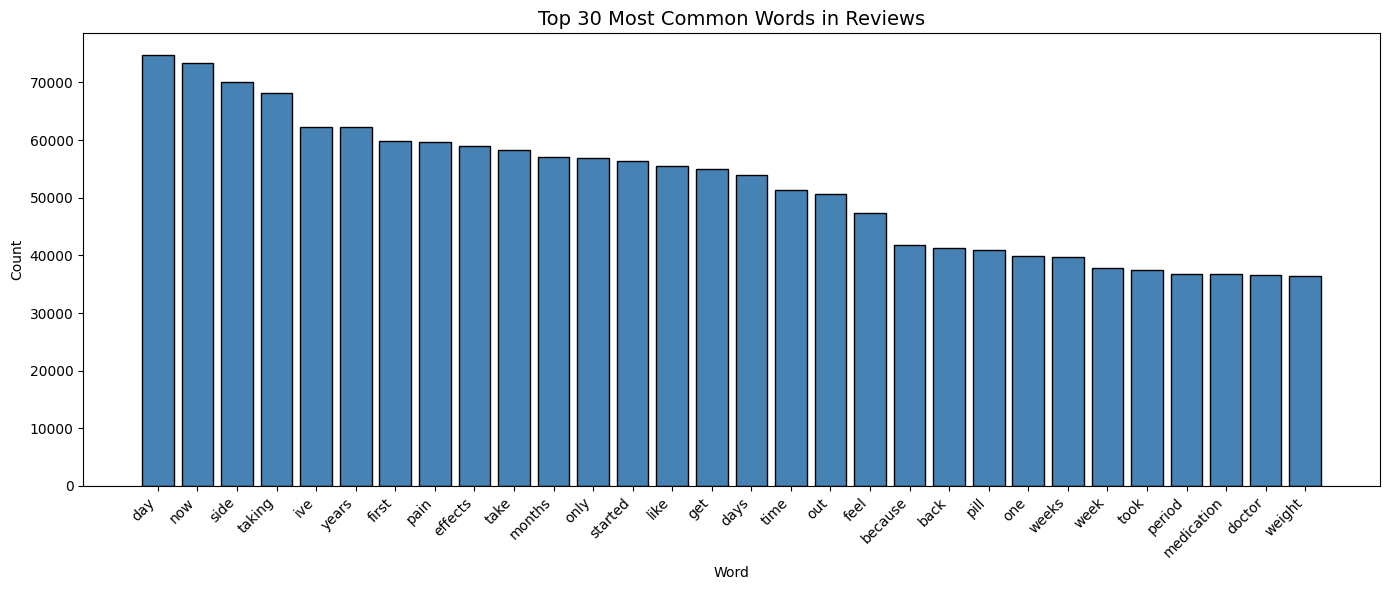

In [23]:
plt.figure(figsize=(14, 6))
plt.bar(top_30['Word'], top_30['Count'], color='steelblue', edgecolor='black')
plt.title('Top 30 Most Common Words in Reviews', fontsize=14)
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Most Common Words Analysis

After basic text cleaning and stop word removal, the top 30 most frequent words reveal a dataset rich in clinical and patient experience language.

**Temporal language dominates** — "day", "days", "weeks", "months" and "years" are among the most frequent words, reflecting patients describing the duration of their treatment and when effects were experienced. This is characteristic of patient-reported outcome data.

**Side effects are a central theme** — "side" and "effects" appear in the top 10, confirming that adverse drug reactions are a primary topic in patient reviews. This is highly relevant for the topic extraction work in a later phase.

**Condition-specific terms are visible** — "weight", "period" and "pill" in the top 30 are consistent with the earlier finding that contraceptives account for 18% of the dataset. These terms will likely dominate topic clusters.

**An HTML encoding artefact is visible** — "ive" appearing in 5th place represents "I've" with the apostrophe stripped, confirming that HTML entity decoding must be a priority in preprocessing.

**Clinical vocabulary is prominent** — "pain", "doctor", "medication" and "pill" confirm the dataset contains substantive clinical language rather than superficial commentary, which is encouraging for NLP modelling quality.

Overall the word frequency analysis confirms this is a clinically rich dataset well suited to healthcare-focused NLP work.

In [24]:
total = len(df)

thresholds = [5, 10, 15, 20]

print("=== SHORT REVIEW ANALYSIS ===")
for threshold in thresholds:
    count = (df['review_length'] < threshold).sum()
    percentage = (count / total * 100).round(2)
    print(f"Under {threshold} words: {count} reviews ({percentage}%)")

# Show some examples of very short reviews
print("\n=== EXAMPLES OF SHORT REVIEWS (under 10 words) ===")
short_reviews = df[df['review_length'] < 10][['drugName', 'condition', 'review', 'rating']]
print(short_reviews.sample(10, random_state=42).to_string())

=== SHORT REVIEW ANALYSIS ===
Under 5 words: 2210 reviews (1.03%)
Under 10 words: 6436 reviews (2.99%)
Under 15 words: 11288 reviews (5.25%)
Under 20 words: 16490 reviews (7.67%)

=== EXAMPLES OF SHORT REVIEWS (under 10 words) ===
           drugName                    condition                                                     review  rating
190494    Imiquimod                    Keratosis  "Possible side effect: Lower backache, muscular fatigue."       6
106669        Amrix                     Migraine                                "Did not work well for me."       3
7371     Paroxetine                Panic Disorde                              "Saved my life, miracle drug"      10
121744     Cefixime              STD Prophylaxis                                             "Worked okay."       7
166327   Lisinopril          High Blood Pressure                  "I experienced coughing and muscle pain."       1
161202    Oxycodone                 Chronic Pain                         

## Short Review Percentage Analysis

Analysis of review length thresholds reveals the following 
distribution of short reviews:

- Under 5 words:  2,210 reviews (1.03%)
- Under 10 words: 6,436 reviews (2.99%)
- Under 15 words: 11,288 reviews (5.25%)
- Under 20 words: 16,490 reviews (7.67%)

**Initial assumption revised** — Visual inspection of reviews 
under 10 words reveals that many carry clear and usable 
sentiment signal despite their brevity. Reviews such as 
"Saved my life, miracle drug" and "Did not work well for me" 
provide sufficient context for sentiment classification, 
contradicting the initial assumption that all sub-10-word 
reviews should be removed.

**Phase 2 decision revised** — The minimum length threshold 
will be set at 5 words rather than 10 words. Reviews under 
5 words (1.03% of the dataset) consistently lack sufficient 
context for reliable sentiment modelling, while reviews 
between 5 and 10 words frequently retain usable signal. 
This decision is data-driven, informed by direct inspection 
of the reviews rather than an arbitrary cutoff.

## Useful Count analysis

The usefulCount column will be used in Phase 5 to rank and 
surface the most helpful reviews to users in the Streamlit 
app when searching by drug or condition, ensuring the most 
informative patient experiences are shown first.

count    215063.000000
mean         28.001004
std          36.346069
min           0.000000
25%           6.000000
50%          16.000000
75%          36.000000
max        1291.000000
Name: usefulCount, dtype: float64


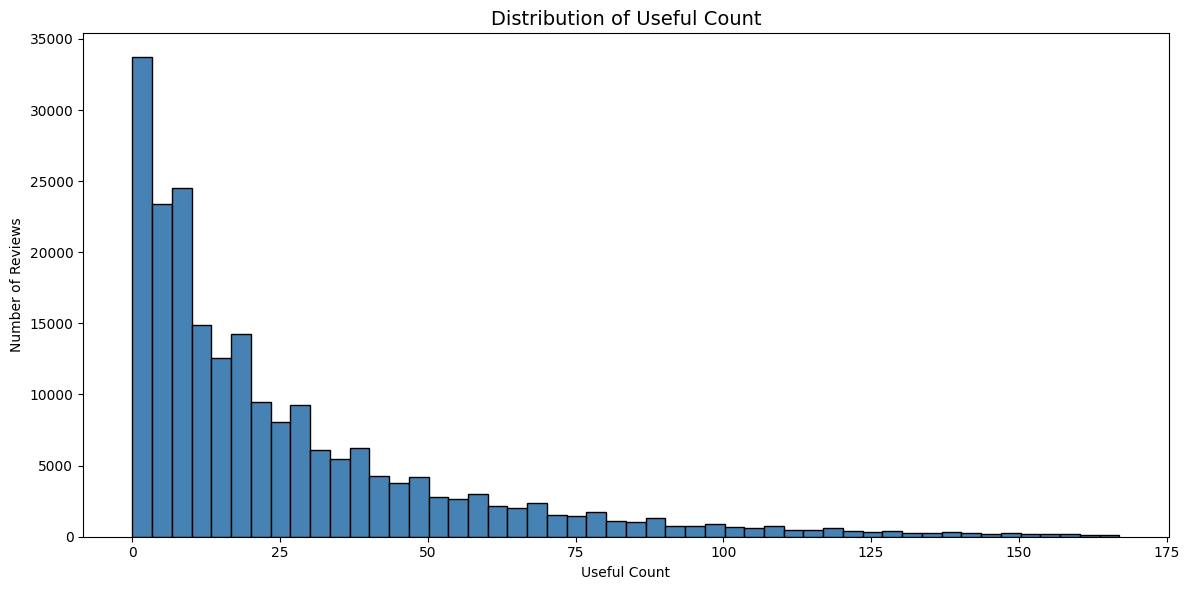

In [25]:
print(df['usefulCount'].describe())

plt.figure(figsize=(12, 6))
df[df['usefulCount'] <= df['usefulCount'].quantile(0.99)]['usefulCount'].plot(
    kind='hist', bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of Useful Count', fontsize=14)
plt.xlabel('Useful Count')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

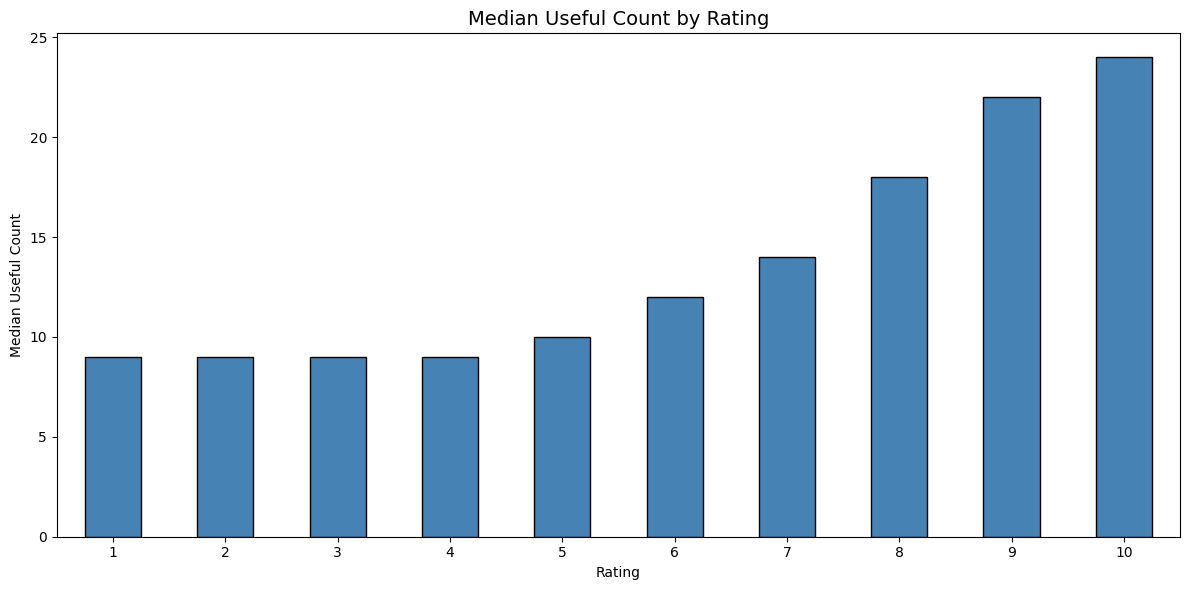

In [26]:
plt.figure(figsize=(12, 6))
df.groupby('rating')['usefulCount'].median().plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.title('Median Useful Count by Rating', fontsize=14)
plt.xlabel('Rating')
plt.ylabel('Median Useful Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

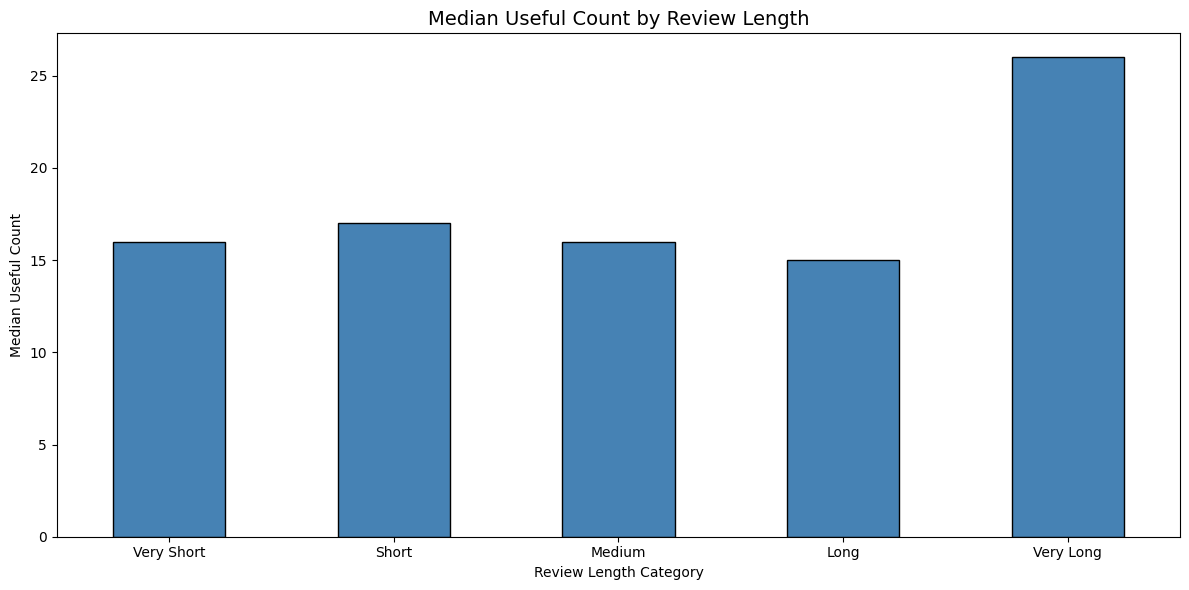

In [27]:
# Bin review length into categories
df['length_category'] = pd.cut(df['review_length'], 
                                bins=[0, 20, 50, 100, 200, 2000],
                                labels=['Very Short', 'Short', 
                                        'Medium', 'Long', 'Very Long'])

plt.figure(figsize=(12, 6))
df.groupby('length_category')['usefulCount'].median().plot(
    kind='bar', color='steelblue', edgecolor='black')
plt.title('Median Useful Count by Review Length', fontsize=14)
plt.xlabel('Review Length Category')
plt.ylabel('Median Useful Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Useful Count Analysis

**Distribution** — The useful count is heavily right-skewed, with 
the majority of reviews receiving between 0 and 25 useful votes. 
A small number of reviews have accumulated significantly higher 
counts, consistent with typical user-generated content platforms 
where a minority of reviews attract disproportionate engagement.

**Relationship with rating** — Higher rated reviews consistently 
receive more useful votes, with ratings 9 and 10 achieving median 
useful counts of 22 and 24 respectively, compared to 9 for ratings 
1 to 4. This suggests patients researching medications find positive 
experiences more helpful, likely reflecting the well-documented 
tendency to seek reassurance before initiating a new treatment — 
a behaviour commonly observed in medication adherence research.

**Relationship with review length** — Review length shows minimal 
relationship with useful count across very short, short, medium 
and long categories, all achieving similar medians of 15 to 17. 
The exception is very long reviews which achieve a median of 26, 
suggesting that exceptionally detailed reviews are valued more 
highly. This indicates content quality and specificity matter 
more than length alone.

**Implication for the Streamlit app** — The usefulCount column 
provides a reliable mechanism for surfacing the most helpful 
reviews to users when searching by drug or condition in Phase 5. 
Given the relationship with rating, the app will naturally 
surface positive reviews more prominently unless filtered 
by sentiment category — a design consideration to address 
in Phase 5.

## Key Findings Summary and Implications for Phase 2

The exploratory analysis of 215,063 patient drug reviews 
has revealed the following key findings:

**Dataset composition:**
- 7 of the top 10 most reviewed drugs are contraceptives, 
  accounting for approximately 18% of all reviews
- Depression is the second most represented condition
- Reviews span from February 2008 to December 2017

**Rating distribution:**
- Heavily skewed positive with rating 10 the most common (~68,000)
- U-shaped distribution with rating 1 the third most common (~29,000)
- Significant class imbalance will need addressing when 
  creating sentiment labels

**Text quality:**
- Mean review length of 85 words — well suited for NLP modelling
- HTML encoding present throughout (confirmed by "ive" artefact 
  in word frequency analysis)
- Numbers, dosages, slang and spelling errors present
- Strong alignment between review text and numeric rating 
  confirms rating-derived labels will be trustworthy

**Preprocessing decisions for Phase 2:**
- Remove reviews under 5 words (1.03% of dataset)
- Decode HTML entities as a priority
- Remove numeric dosage references
- Handle missing values and HTML fragments in condition column
- Convert date column to datetime format